In [1]:
import pandas as pd
import ast

In [4]:
df = pd.read_excel('annotate_data.xlsx', sheet_name='Sheet2')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24029 entries, 0 to 24028
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        24029 non-null  object
 1   annotators_id                  24029 non-null  object
 2   text                           24015 non-null  object
 3   initial_paragraph              1287 non-null   object
 4   topic                          24029 non-null  object
 5   is_noise_or_spam_text          24029 non-null  object
 6   related_to_election_2024       24029 non-null  object
 7   toxicity                       24029 non-null  object
 8   polarized                      24029 non-null  object
 9   profanity_obscenity            24029 non-null  object
 10  threat_incitement_to_violence  24029 non-null  object
 11  insults                        24029 non-null  object
 12  identity_attack                24029 non-null  object
 13  s

In [6]:
cols = [
'is_noise_or_spam_text',
'related_to_election_2024',
'toxicity',
'polarized',
'profanity_obscenity',
'threat_incitement_to_violence',
'insults',
'identity_attack',
'sexually_explicit'
]

for col in cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else x)

In [7]:
print(df['toxicity'].iloc[0])
print(type(df['toxicity'].iloc[0]))

['0', '0']
<class 'list'>


In [8]:
def majority_vote(x):
    x = [int(i) for i in x]
    return round(sum(x)/len(x))

for col in cols:
    df[col] = df[col].apply(majority_vote)

In [29]:
df.head(2)

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,2026-01-01 00:00:00,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,â€œï¸Jurnalis Hana Mahamed kembali tampil di ...,UNKNOWN,0,0,0,0,0,0,0,0,0
1,2026-01-10 00:00:00,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,NaN,Disabilitas,0,1,0,1,0,0,0,0,0


In [9]:
labels = [
'is_noise_or_spam_text',
'related_to_election_2024',
'toxicity',
'polarized',
'profanity_obscenity',
'threat_incitement_to_violence',
'insults',
'identity_attack',
'sexually_explicit'
]

for col in labels:
    print(df[col].value_counts())

is_noise_or_spam_text
0    22667
1     1362
Name: count, dtype: int64
related_to_election_2024
0    22477
1     1552
Name: count, dtype: int64
toxicity
0    22558
1     1471
Name: count, dtype: int64
polarized
0    20594
1     3435
Name: count, dtype: int64
profanity_obscenity
0    23826
1      203
Name: count, dtype: int64
threat_incitement_to_violence
0    23953
1       76
Name: count, dtype: int64
insults
0    23437
1      592
Name: count, dtype: int64
identity_attack
0    23469
1      560
Name: count, dtype: int64
sexually_explicit
0    23999
1       30
Name: count, dtype: int64


# PREPROCESS (KOMBINASI LLM N NLP)

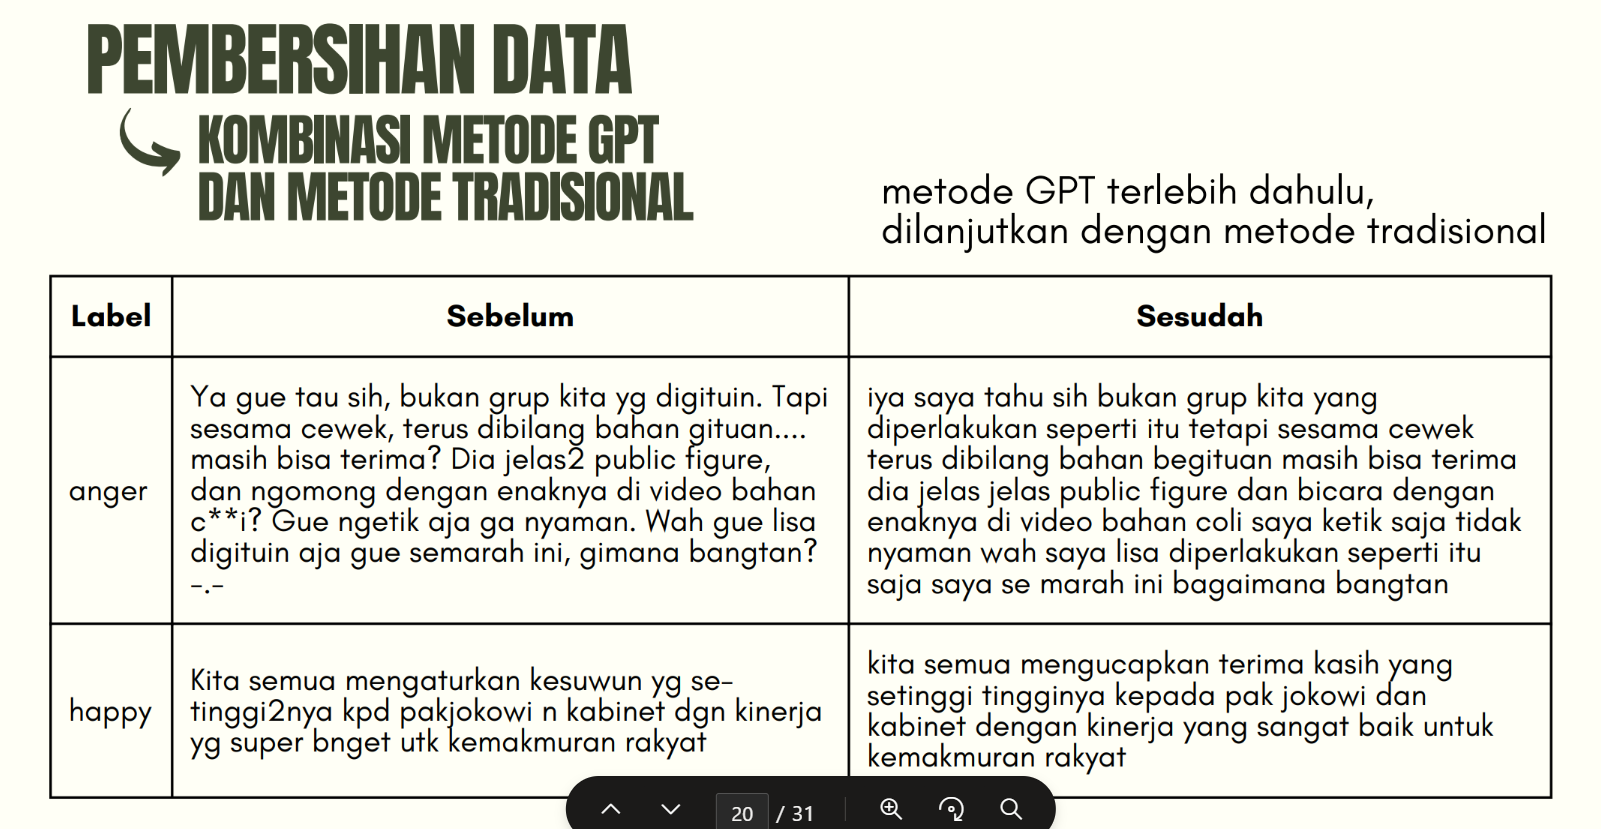

### Drop Spam Text
Already drop the red rows

In [10]:
df = df[df['is_noise_or_spam_text'] == 0]

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 22667 entries, 0 to 24028
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        22667 non-null  object
 1   annotators_id                  22667 non-null  str   
 2   text                           22656 non-null  str   
 3   initial_paragraph              1277 non-null   str   
 4   topic                          22667 non-null  str   
 5   is_noise_or_spam_text          22667 non-null  int64 
 6   related_to_election_2024       22667 non-null  int64 
 7   toxicity                       22667 non-null  int64 
 8   polarized                      22667 non-null  int64 
 9   profanity_obscenity            22667 non-null  int64 
 10  threat_incitement_to_violence  22667 non-null  int64 
 11  insults                        22667 non-null  int64 
 12  identity_attack                22667 non-null  int64 
 13  sexually_explicit

### Sampling Data

In [11]:
df_sample = df.groupby(['toxicity','polarized'], group_keys=False)\
              .apply(lambda x: x.sample(min(len(x), 500)))

C:\Users\evely\AppData\Local\Temp\ipykernel_18012\1143871040.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 500)))


In [12]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 19047 to 18461
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        2000 non-null   object
 1   annotators_id                  2000 non-null   object
 2   text                           2000 non-null   object
 3   initial_paragraph              85 non-null     object
 4   topic                          2000 non-null   object
 5   is_noise_or_spam_text          2000 non-null   int64 
 6   related_to_election_2024       2000 non-null   int64 
 7   toxicity                       2000 non-null   int64 
 8   polarized                      2000 non-null   int64 
 9   profanity_obscenity            2000 non-null   int64 
 10  threat_incitement_to_violence  2000 non-null   int64 
 11  insults                        2000 non-null   int64 
 12  identity_attack                2000 non-null   int64 
 13  sex

In [13]:
df_s1 = df_sample.iloc[0:1000]

In [14]:
df_s2 = df_sample.iloc[1000:2000]

In [18]:
temp = df[df['text'] == 'Kasian israel ga ada temenya uhuuyyy']
temp

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
15544,2041-02-01 00:00:00,"['12', '18', '30', '24']",Kasian israel ga ada temenya uhuuyyy,NaN,Jewish,0,0,1,0,0,0,0,0,0


In [17]:
df_s2

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
15544,2041-02-01 00:00:00,"['12', '18', '30', '24']",Kasian israel ga ada temenya uhuuyyy,NaN,Jewish,0,0,1,0,0,0,0,0,0
16605,3-1070,"['20', '18']",Me : mas yg ini harganya brp Mas2 yg jualan : ...,NaN,Disabilitas,0,0,1,0,0,0,0,0,0
9442,2029-02-01 00:00:00,"['20', '23', '31']",Terkutuklah Negara Zionis Israel dan pendukung...,NaN,Jewish,0,0,1,0,0,0,0,0,0
9229,1993-02-01 00:00:00,"['10', '20']",Pencalonan gibran jadi cawapres cacat hukum Gi...,NaN,Disabilitas,0,1,1,0,0,0,1,0,0
19517,4-1272,"['21', '18', '26', '22']","Semua sifat, watak & perbuatan asli Israel sud...",NaN,Jewish,0,0,1,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17247,3-1686,['20'],Paman Cawapres Cacat Moral! Gibran dan Anwar U...,NaN,Disabilitas,0,1,1,1,0,0,1,0,0
4618,102-4,"['8', '13', '7', '11', '15', '3', '12', '2', '...",Postingan Dokter Tifa @DokterTifa 10 tahun rak...,provokator,Disabilitas,0,0,1,1,0,0,1,0,0
21276,1997-04-01 00:00:00,['20'],Teroris israel terus membantai anak anak pales...,NaN,Jewish,0,0,1,1,0,0,0,1,0
10451,1969-02-01 00:00:00,"['3', '29', '25']",Israel ini cuma mau banyak2an ngabisin nyawa w...,NaN,Jewish,0,0,1,1,0,1,0,0,0


## DATA CLEANING

### LLM

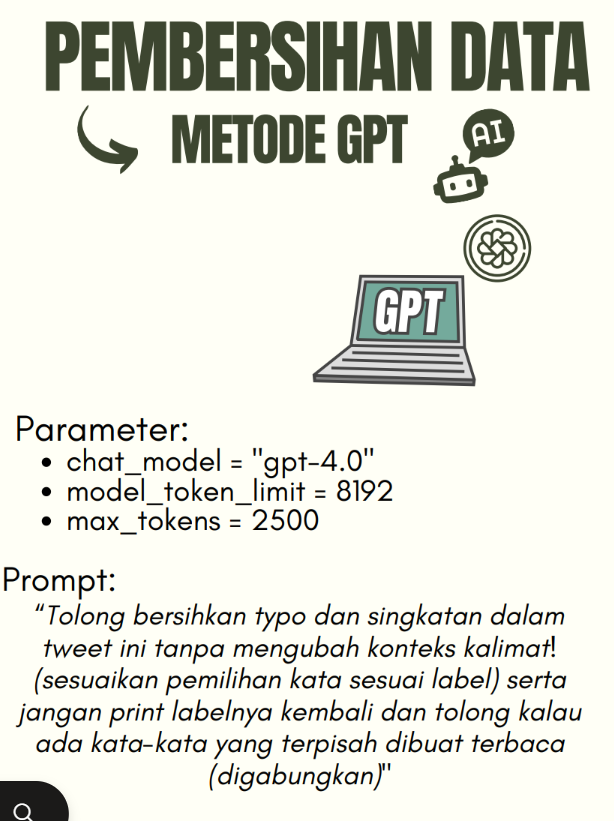

In [17]:
# Parameter:
""" 
chat_model =
gpt-4.0"
model_token_limit = 8192
max_tokens = 2500
"""

# Prompt:
"""
Tolong bersihkan typo dan singkatan dalam
tweet ini tanpa mengubah konteks kalimat!
(sesuaikan pemilihan kata sesuai label) serta
jangan print labelnya kembali dan tolong kalau
ada kata-kata yang terpisah dibuat terbaca
(digabungkan)
"""


'\nTolong bersihkan typo dan singkatan dalam\ntweet ini tanpa mengubah konteks kalimat!\n(sesuaikan pemilihan kata sesuai label) serta\njangan print labelnya kembali dan tolong kalau\nada kata-kata yang terpisah dibuat terbaca\n(digabungkan)\n'

In [19]:
import os
os.environ["GROQ_API_KEY"] = "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"

In [6]:
import asyncio
import re
import time
import json
import os
import pandas as pd
from tqdm.asyncio import tqdm_asyncio
from concurrent.futures import ThreadPoolExecutor
from openai import OpenAI

# =========================
# CONFIG
# =========================
os.environ["GROQ_API_KEY"] = "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"

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "openai/gpt-oss-120b"
BATCH_SIZE = 3
REQUEST_DELAY = 3
MAX_CONCURRENT = 1
# MAX_CONCURRENT  = 2   # bisa dinaikin di Groq
MAX_RETRIES     = 5
# BATCH_SIZE      = 10
CHECKPOINT_FILE = "checkpoint_cleaned_groq_s2.json"
# REQUEST_DELAY   = 1.5   # Groq lebih longgar

executor = ThreadPoolExecutor(max_workers=MAX_CONCURRENT)

# =========================
# RATE LIMITER (lebih santai)
# =========================
class SimpleRateLimiter:
    def __init__(self, delay_seconds):
        self.delay = delay_seconds
        self.lock = asyncio.Lock()
        self.last_call = 0.0

    async def acquire(self):
        async with self.lock:
            elapsed = time.monotonic() - self.last_call
            if elapsed < self.delay:
                await asyncio.sleep(self.delay - elapsed)

    def release(self):
        self.last_call = time.monotonic()

rate_limiter = SimpleRateLimiter(delay_seconds=REQUEST_DELAY)

# =========================
# CHECKPOINT
# =========================
def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        try:
            with open(CHECKPOINT_FILE, "r", encoding="utf-8") as f:
                data = json.load(f)
            print(f"[CHECKPOINT] Resume dari {len(data)} data.")
            return data
        except:
            os.remove(CHECKPOINT_FILE)
    return {}

checkpoint_lock = asyncio.Lock()

async def save_checkpoint(done):
    async with checkpoint_lock:
        with open(CHECKPOINT_FILE, "w", encoding="utf-8") as f:
            json.dump(done, f, ensure_ascii=False)

# =========================
# PROMPT
# =========================
def build_prompt(texts):
    joined = "\n".join([f"{i+1}. {t}" for i, t in enumerate(texts)])

    return f"""Kamu adalah ahli normalisasi teks bahasa Indonesia dari media sosial.
Tolong bersihkan typo dan singkatan dalam
tweet ini tanpa mengubah konteks kalimat!
(sesuaikan pemilihan kata sesuai label) serta
jangan print labelnya kembali dan tolong kalau
ada kata-kata yang terpisah dibuat terbaca
(digabungkan)
TUGAS:
- Bersihkan typo dan singkatan dalam text tanpa mengubah konteks kalimat (sesuaikan pemilihan kata sesuai label) serta
jangan print labelnya kembali 
- Gabungkan kata terpisah
- Jangan hilangkan kata kasar/toxic

FORMAT:
- Tepat {len(texts)} baris
- "1. ...", "2. ...", dst
- Tanpa penjelasan tambahan

INPUT:
{joined}

OUTPUT:"""

# =========================
# PARSER
# =========================
def parse_output(raw_text):
    lines = raw_text.strip().split("\n")
    results = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
        cleaned = re.sub(r"^\d+[\.\)\-\s]+", "", line).strip()
        results.append(cleaned)

    return results

# =========================
# PROCESS SINGLE BATCH
# =========================
async def process_batch(batch, indices, done, pbar):
    loop = asyncio.get_event_loop()

    for attempt in range(MAX_RETRIES):
        try:
            await rate_limiter.acquire()

            prompt = build_prompt(batch)

            response = await loop.run_in_executor(
                executor,
                lambda: client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0
                )
            )

            rate_limiter.release()

            raw = response.choices[0].message.content
            cleaned = parse_output(raw)

            if len(cleaned) == len(batch):
                result = dict(zip([str(i) for i in indices], cleaned))
                done.update(result)
                await save_checkpoint(done)

                pbar.update(len(batch))
                return

            print(f"[WARN] retry {attempt+1}")

        except Exception as e:
            print("[ERROR]", e)
            await asyncio.sleep(2)

    # fallback
    result = dict(zip([str(i) for i in indices], batch))
    done.update(result)
    await save_checkpoint(done)
    pbar.update(len(batch))

# =========================
# MAIN PIPELINE
# =========================
async def process_all(df):
    from tqdm.auto import tqdm

    texts = df['text'].tolist()
    indices = df.index.tolist()

    done = load_checkpoint()

    remaining = [
        (texts[i], indices[i])
        for i in range(len(texts))
        if str(indices[i]) not in done
    ]

    batches = []
    for i in range(0, len(remaining), BATCH_SIZE):
        chunk = remaining[i:i+BATCH_SIZE]
        batches.append(([x[0] for x in chunk], [x[1] for x in chunk]))

    semaphore = asyncio.Semaphore(MAX_CONCURRENT)

    with tqdm(total=len(texts), initial=len(done), desc="Groq Cleaning") as pbar:

        async def run(batch, idx):
            async with semaphore:
                await process_batch(batch, idx, done, pbar)

        tasks = [run(b, i) for b, i in batches]
        await asyncio.gather(*tasks)

    df = df.copy()
    df['cleaned_text'] = df.index.map(lambda i: done.get(str(i), df.loc[i, 'text']))
    return df

# =========================
# RUN
# =========================
df_result = await process_all(df_s2)

df_result[['text','cleaned_text']].head(20)

In [21]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 15544 to 18461
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        1000 non-null   object
 1   annotators_id                  1000 non-null   object
 2   text                           1000 non-null   object
 3   initial_paragraph              27 non-null     object
 4   topic                          1000 non-null   object
 5   is_noise_or_spam_text          1000 non-null   int64 
 6   related_to_election_2024       1000 non-null   int64 
 7   toxicity                       1000 non-null   int64 
 8   polarized                      1000 non-null   int64 
 9   profanity_obscenity            1000 non-null   int64 
 10  threat_incitement_to_violence  1000 non-null   int64 
 11  insults                        1000 non-null   int64 
 12  identity_attack                1000 non-null   int64 
 13  sex

In [22]:
import json

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

j3 = load_json("checkpoint_cleaned_groq_s2.json")

# merge (priority: j3 > j2 > j1 kalau ada key sama)
merged = {**j3}

In [23]:
df_final = df.copy()
df_final['cleaned_text'] = df.index.map(lambda i : merged.get(str(i), None))

In [24]:
df_final = df_final[df_final['cleaned_text'].isna() == False]

In [25]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 2 to 24002
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        1000 non-null   object
 1   annotators_id                  1000 non-null   object
 2   text                           1000 non-null   object
 3   initial_paragraph              27 non-null     object
 4   topic                          1000 non-null   object
 5   is_noise_or_spam_text          1000 non-null   int64 
 6   related_to_election_2024       1000 non-null   int64 
 7   toxicity                       1000 non-null   int64 
 8   polarized                      1000 non-null   int64 
 9   profanity_obscenity            1000 non-null   int64 
 10  threat_incitement_to_violence  1000 non-null   int64 
 11  insults                        1000 non-null   int64 
 12  identity_attack                1000 non-null   int64 
 13  sexuall

In [26]:
df_final.to_csv('preprocessed_data_s2.csv') 

In [ ]:
# df_final.head(1)

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text
6,1-1003,"['10', '18', '32']",Paus Fransiskus Memulai Kunjungan Sederhana Ke...,NaN,Kristen,0,0,0,0,0,0,0,0,0,Paus Fransiskus memulai kunjungan sederhana ke...


In [ ]:
# df_final.to_csv('testtt.csv')

### NLP

In [3]:
df_final_S1 = pd.read_csv('preprocessed_data.csv')
df_final_S2 = pd.read_csv('preprocessed_data_s2.csv')

In [5]:
df_final = pd.concat([df_final_S1, df_final_S2])

In [6]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Unnamed: 0                     2000 non-null   int64 
 1   text_id                        2000 non-null   object
 2   annotators_id                  2000 non-null   object
 3   text                           2000 non-null   object
 4   initial_paragraph              97 non-null     object
 5   topic                          2000 non-null   object
 6   is_noise_or_spam_text          2000 non-null   int64 
 7   related_to_election_2024       2000 non-null   int64 
 8   toxicity                       2000 non-null   int64 
 9   polarized                      2000 non-null   int64 
 10  profanity_obscenity            2000 non-null   int64 
 11  threat_incitement_to_violence  2000 non-null   int64 
 12  insults                        2000 non-null   int64 
 13  identity_

In [9]:
df_final['polarized'].value_counts()

polarized
1    1000
0    1000
Name: count, dtype: int64

In [13]:
temp = df_final[df_final['toxicity'] == 1]
tempp = temp[temp['polarized'] == 0]
temp['polarized'].value_counts()

polarized
0    500
1    500
Name: count, dtype: int64

In [ ]:
# df_final.to_csv('llm_preprocessed_data_sampple_2000.csv')

In [2]:
df_final = pd.read_csv('/kaggle/input/datasets/evelynuntariady/sample-preprocessed-data/llm_preprocessed_data_sampple_2000.csv')

In [3]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [4]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
from tqdm import tqdm
tqdm.pandas()

df_final['processed_text'] = df_final['cleaned_text'].progress_apply(
    lambda x: preprocess_text(x, slang_dict)
)

100%|██████████| 2000/2000 [00:00<00:00, 18566.01it/s]


### Split Data

In [6]:
x = df_final['processed_text']
y = df_final['toxicity']

In [7]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

In [ ]:
# df_final.drop(columns = ['text_id'], inplace=True)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [9]:
train_df = pd.DataFrame({"processed_text": x_train, "label": y_train})
test_df = pd.DataFrame({"processed_text": x_test, "label": y_test})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})


# Modeling

In [10]:
from huggingface_hub import login
login("ini_key_pribadi")

## Stage 1

In [11]:
from transformers import AutoTokenizer, Trainer, TrainingArguments, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [12]:
def tokenize(batch):
    return tokenizer(
        batch["processed_text"],   # atau cleaned_text / processed_text
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [13]:
tokenized_datasets_1 = dataset.map(tokenize, batched=True)

tokenized_datasets_1 = tokenized_datasets_1.remove_columns(["processed_text"])
tokenized_datasets_1 = tokenized_datasets_1.rename_column("label", "labels")
tokenized_datasets_1.set_format("torch")

train_dataset_1 = tokenized_datasets_1["train"]
test_dataset_1 = tokenized_datasets_1["test"]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [14]:
from transformers import AutoModelForSequenceClassification

model_s1 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [16]:
from transformers import TrainingArguments, Trainer

args_s1 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    train_dataset=train_dataset_1,
    eval_dataset=test_dataset_1,
    compute_metrics=compute_metrics_s1
)


In [17]:
trainer_s1.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.278504,1.057360,0.727500,0.760440
2,0.831976,0.967170,0.782500,0.794326
3,1.040414,0.970178,0.782500,0.795294
4,0.535168,0.977022,0.770000,0.778846
5,0.420460,1.000287,0.785000,0.798122


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=500, training_loss=0.8826731321811676, metrics={'train_runtime': 156.8806, 'train_samples_per_second': 50.994, 'train_steps_per_second': 3.187, 'total_flos': 526222110720000.0, 'train_loss': 0.8826731321811676, 'epoch': 5.0})

In [18]:
history = trainer_s1.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

In [19]:
from matplotlib import pyplot as plt

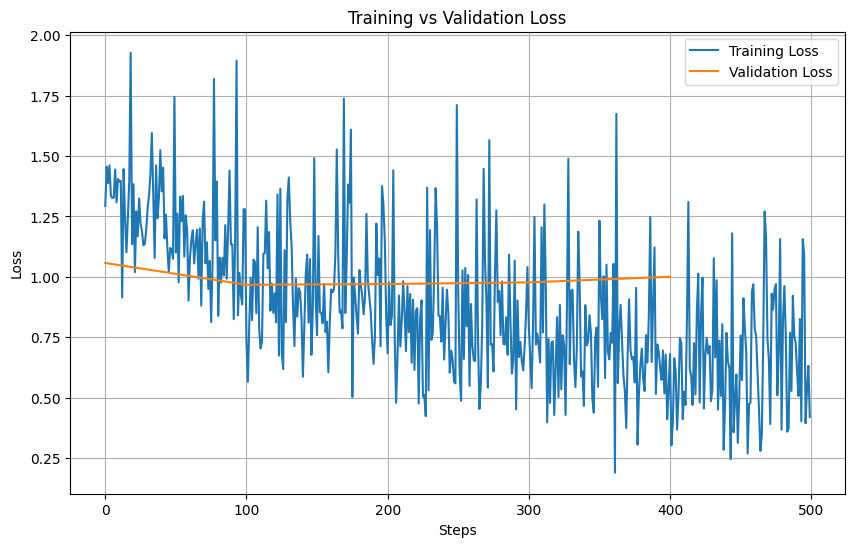

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
evaluation_results1 = trainer_s1.evaluate()
print(evaluation_results1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.9667854309082031, 'eval_accuracy': 0.7825, 'eval_f1': 0.7943262411347518, 'eval_runtime': 2.2621, 'eval_samples_per_second': 176.829, 'eval_steps_per_second': 11.052, 'epoch': 5.0}


In [22]:
pred1 = trainer_s1.predict(test_dataset_1)
pred_label1 = pred1.predictions.argmax(axis=1)

y_test_numeric = y_test

print(classification_report(y_test_numeric, pred_label1))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

           0       0.82      0.72      0.77       200
           1       0.75      0.84      0.79       200

    accuracy                           0.78       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.79      0.78      0.78       400



## Stage 2

In [45]:
def add_polarization_text(row):
    return f"[POL={row['polarized']}] {row['processed_text']}"

df_final["text_with_pol"] = df_final.apply(add_polarization_text, axis=1)

In [47]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

X = df_final["text_with_pol"]
y2 = df_final[LABEL_COLS]

In [26]:
!pip install iterative-stratification

In [48]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import numpy as np

X_np = X.values
y_np = y2.values

mskf = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)

train_idx, test_idx = next(mskf.split(X_np, y_np))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]

In [49]:
y_train = y_train.astype(float)
y_test  = y_test.astype(float)

In [50]:
from datasets import Dataset

train_df = X_train.to_frame()
train_df["labels"] = y_train.values.tolist()

test_df = X_test.to_frame()
test_df["labels"] = y_test.values.tolist()

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

In [51]:
from transformers import AutoTokenizer

tokenizer_s2 = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

In [53]:
def tokenize(batch):
    return tokenizer_s2(
        batch["text_with_pol"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [54]:
from transformers import AutoModelForSequenceClassification

model_s2 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [55]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics_s2(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [56]:
from transformers import TrainingArguments, Trainer

args_s2 = TrainingArguments(
    output_dir="./model_toxicity_s2",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s2 = Trainer(
    model=model_s2,
    args=args_s2,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics_s2
)


In [57]:
trainer_s2.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.463350,0.552637,0.000000,0.000000
2,0.427040,0.511371,0.000000,0.000000
3,0.442480,0.495520,0.201681,0.115039
4,0.399021,0.491583,0.324324,0.172304
5,0.434427,0.487532,0.349650,0.215991


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=565, training_loss=0.5170712733954455, metrics={'train_runtime': 173.8516, 'train_samples_per_second': 51.768, 'train_steps_per_second': 3.25, 'total_flos': 592015820544000.0, 'train_loss': 0.5170712733954455, 'epoch': 5.0})

In [58]:
history_s2 = trainer_s2.state.log_history
train_loss_s2 = [x['loss'] for x in history if 'loss' in x]
val_loss_s2 = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs_s2 = [x['epoch'] for x in history if 'eval_loss' in x]

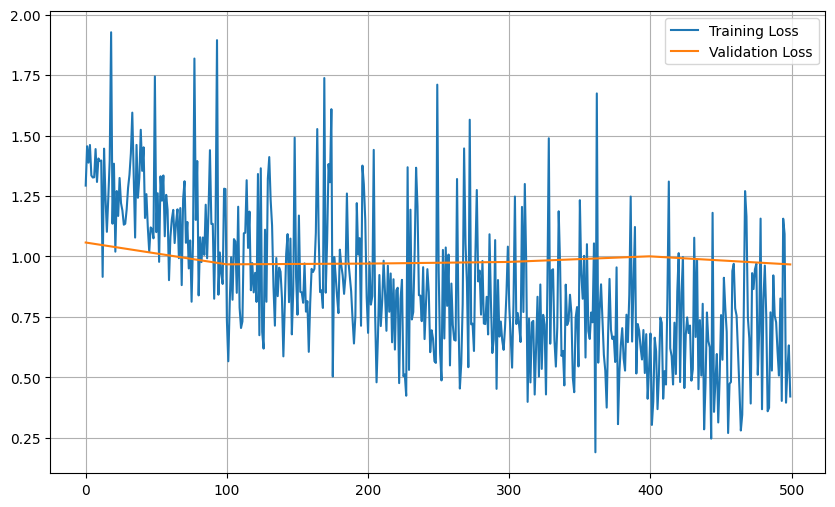

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss_s2, label='Training Loss')

plt.plot(
    np.linspace(0, len(train_loss_s2)-1, len(val_loss_s2)),
    val_loss_s2,
    label='Validation Loss'
)

plt.legend()
plt.grid(True)
plt.show()

In [60]:
evaluation_results2 = trainer_s2.evaluate()
print(evaluation_results2)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.48753175139427185, 'eval_f1_micro': 0.34965034965034963, 'eval_f1_macro': 0.21599079666379062, 'eval_runtime': 1.2133, 'eval_samples_per_second': 164.845, 'eval_steps_per_second': 10.715, 'epoch': 5.0}


In [61]:
pred2 = trainer_s2.predict(test_ds)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [62]:
import numpy as np

logits = pred2.predictions
probs = 1 / (1 + np.exp(-logits))

threshold = 0.5  # bisa tuning nanti
pred_label2 = (probs > threshold).astype(int)

y_true = y_test.values
from sklearn.metrics import classification_report

print(classification_report(y_true, pred_label2, target_names=LABEL_COLS))

                               precision    recall  f1-score   support

                      insults       0.52      0.28      0.36        40
              identity_attack       0.58      0.29      0.39        38
threat_incitement_to_violence       0.00      0.00      0.00         5
          profanity_obscenity       1.00      0.20      0.33        15
            sexually_explicit       0.00      0.00      0.00         2

                    micro avg       0.58      0.25      0.35       100
                    macro avg       0.42      0.15      0.22       100
                 weighted avg       0.58      0.25      0.34       100
                  samples avg       0.09      0.10      0.09       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

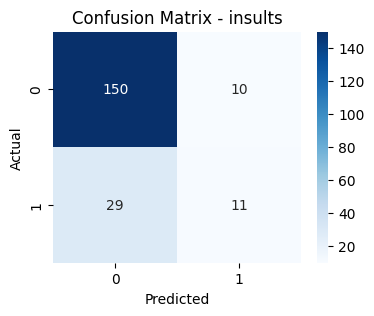

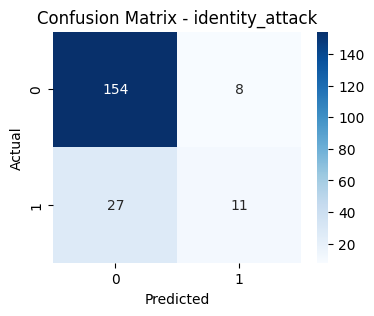

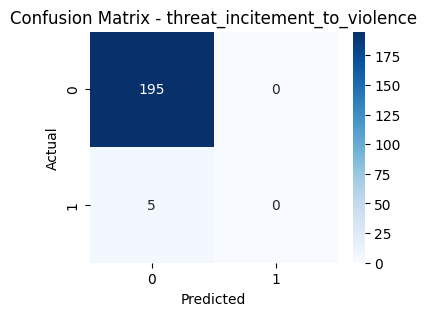

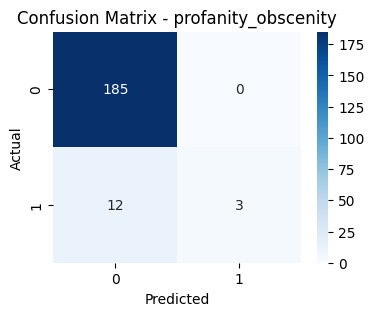

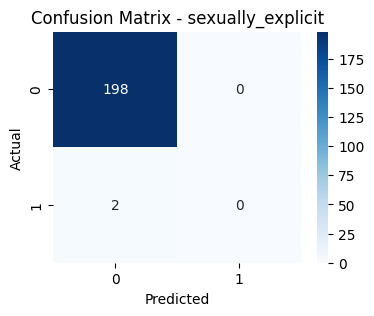

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(y_true[:, i], pred_label2[:, i])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()